# Walmart Hurricane Project

# Data Loading

We start by printing the file path names of each input file.

Using the datapath, we read csv files in as pandas dataframes.

We use the Open-Meteo free weather API to retrieve historical weather data (precipitation, wind speed, and pressure).

In [65]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/andrewniscool/midterm-dataset/walmart_transactions.csv
/kaggle/input/datasets/andrewniscool/midterm-dataset/inventory_and_sales.db
/kaggle/input/datasets/andrewniscool/midterm-dataset/distribution_centers.csv
/kaggle/input/datasets/andrewniscool/midterm-dataset/product_catalog.csv
/kaggle/input/datasets/andrewniscool/midterm-dataset/store_locations.csv


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3
import requests

DATA_PATH = '/kaggle/input/datasets/andrewniscool/midterm-dataset/'

transactions = pd.read_csv(DATA_PATH + "walmart_transactions.csv")
stores = pd.read_csv(DATA_PATH + "store_locations.csv")
products = pd.read_csv(DATA_PATH + "product_catalog.csv")
dcs = pd.read_csv(DATA_PATH + "distribution_centers.csv")

conn = sqlite3.connect(DATA_PATH + "inventory_and_sales.db")

In [67]:
from IPython.display import display

#showing snippets of messy data before cleaning
display(transactions.head())
display(stores.head())
display(products.head())
display(dcs.head())

,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price
0,TXN012636,FL-710,2024-09-13T09:48:13,PNUTBTR-16,PEANUT BUTTER,Grocery,1,3.15
1,TXN000759,fl-412,2024-09-02 20:30:20,CNSOUP-01,CANNED SOUP,GROCERY,1,2.02
2,TXN003338,FL-105,2024-09-06 10:06:00,TOILETPAPER12,Toilet Paper 12-Roll,Household Essentials,2,10.47
3,TXN025020,FL-330,2024-09-30 06:29:08,ROKU-STD,Roku Streaming Stick,ELECTRONICS,1,28.59
4,TXN015797,FL-302,2024-09-15 15:59:42,BEER-24,Light Beer 24pk,Alcoholic Beverages,3,18.82


,store_id,store_name,city,state,zip_code,latitude,longitude,region
0,FL-239,Walmart Supercenter Orlando,Orlando,FL,32801,28.5383,-81.3792,Central
1,FL-105,Walmart Supercenter Tampa,Tampa,FL,33602,27.9506,-82.4572,West
2,FL-330,Walmart Supercenter Miami,Miami,FL,33101,25.7617,-80.1918,South
3,FL-412,Walmart Supercenter Jacksonville,Jacksonville,FL,32099,30.3322,-81.6557,North
4,FL-287,Walmart Neighborhood Market Kissimmee,Kissimmee,Florida,34741,28.2920,-81.4076,Central


,sku,product_name,category,subcategory,unit_cost,supplier,package_size
0,PT-12,pop-tarts strawberry,Breakfast Foods,NaN,1.93,Johnson & Johnson,4-pack
1,SKU#459812,Strawberry Pop-Tart,Breakfast,Pop-Tarts,2.26,Roku Inc,4pk
2,POPTART-STRAW,Pop-Tarts Strawberry,Breakfast,NaN,2.11,Sara Lee,6 pack
3,PT_STRAWBERRY,pop-tarts strawberry,breakfast,Pop-Tarts,NaN,Campbell's,4 pack
4,WTR-24,BOTTLED WATER 24PK,Emergency Supplies,Bottled,2.64,Sara Lee,1 pack


,dc_id,dc_name,city,state,avg_daily_shipments,surge_capacity,distance_to_orlando_mi,cost_per_shipment
0,DC-JAX,Jacksonville Distribution Center,Jacksonville,FL,500,1000,141,245.0
1,DC-ATL,Atlanta Distribution Center,Atlanta,GA,400,700,438,412.5
2,DC-DAL,Dallas Distribution Center,Dallas,TX,300,600,1108,687.0
3,DC-MIA,Miami Distribution Center,Miami,FL,350,~750,235,298.0
4,DC-BHM,Birmingham Distribution Center,Birmingham,AL,250,500,503,NaN


### Weather Data citation
Weather data sourced from Open-Meteo Historical API:
https://archive-api.open-meteo.com/v1/archive

In [68]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 27.95,
    "longitude": -82.46,
    "start_date": "2024-09-01",
    "end_date": "2024-09-30",
    "hourly": ["precipitation", "wind_speed_10m", "pressure_msl"],
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
data = response.json()

weather_df = pd.DataFrame({
    "datetime": data["hourly"]["time"],
    "precipitation": data["hourly"]["precipitation"],
    "wind": data["hourly"]["wind_speed_10m"],
    "pressure": data["hourly"]["pressure_msl"]
})

#Showing messy data before we clean anything
weather_df.head()

,datetime,precipitation,wind,pressure
0,2024-09-01T00:00,0.0,12.4,1014.5
1,2024-09-01T01:00,0.0,14.1,1014.4
2,2024-09-01T02:00,0.0,13.1,1013.9
3,2024-09-01T03:00,0.0,9.7,1013.6
4,2024-09-01T04:00,0.0,7.4,1013.4


# Data Cleaning

### Transactions Cleaning
To prepare the transaction data for analysis, several cleaning steps were required.

Timestamps were converted to datetime format to enable time-based analysis, and numeric columns such as quantity and unit_price were converted from strings to numeric types. A date column was created by converting the timestamp to just a date to allow for daily analysis. A sales column was created by multiplying quantity by unit_price, allowing us to calculate total revenue per transaction.

We dropped any transactions that were entirely duplicates or had missing values such as quantity, unit_price, or timestamp.

Category names were standardized by trimming whitespace, converting to lowercase, and consolidating inconsistent labels such as “breakfast foods” → “breakfast” and “health & wellness” → “health”.

In [69]:
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], errors="coerce", format="mixed")

transactions["quantity"] = pd.to_numeric(transactions["quantity"], errors="coerce")
transactions["unit_price"] = pd.to_numeric(transactions["unit_price"], errors="coerce")

transactions["date"] = transactions["timestamp"].dt.date
transactions["sales"] = transactions["quantity"] * transactions["unit_price"]

transactions = transactions.drop_duplicates()
transactions = transactions[transactions["quantity"] > 0]
transactions = transactions.dropna(subset=["timestamp","quantity","unit_price"])

transactions["category"] = (
    transactions["category"]
    .str.strip()
    .str.lower()
)

#combining categories that have similar names but describe the same things
category_map = {
    "breakfast foods": "breakfast",
    "emergency supplies": "emergency",
    "health & wellness" : "health",
    "alcoholic beverages" : "alcohol",
    "games & entertainment": "entertainment",
    "grocery": "groceries",
    "baby products": "baby",
    "household essentials": "household"
}
transactions["category"] = transactions["category"].replace(category_map)

#Showing snippets of data after cleaning
transactions.head()

,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price,date,sales
0,TXN012636,FL-710,2024-09-13 09:48:13,PNUTBTR-16,PEANUT BUTTER,groceries,1,3.15,2024-09-13,3.15
1,TXN000759,fl-412,2024-09-02 20:30:20,CNSOUP-01,CANNED SOUP,groceries,1,2.02,2024-09-02,2.02
2,TXN003338,FL-105,2024-09-06 10:06:00,TOILETPAPER12,Toilet Paper 12-Roll,household,2,10.47,2024-09-06,20.94
3,TXN025020,FL-330,2024-09-30 06:29:08,ROKU-STD,Roku Streaming Stick,electronics,1,28.59,2024-09-30,28.59
4,TXN015797,FL-302,2024-09-15 15:59:42,BEER-24,Light Beer 24pk,alcohol,3,18.82,2024-09-15,56.46


### Pop-Tart Cleaning

Product names were standardized by trimming whitespace, converting to lowercase, and consolidating pop-tart labels into a new column "product_clean".

All Pop-Tart product variants were standardized into a single product identifier called "pop_tarts". This was done by detecting product names containing the word "tart" and replacing them with a unified label. Consolidating these product names allows the total demand for Pop-Tarts to be analyzed accurately. A new dataframe "poptart_rows" was created to hold all Pop-Tart transactions.

In [70]:
transactions["product_clean"] = transactions["product_name"].str.lower()

transactions.loc[
    transactions["product_clean"].str.contains("tart", na=False),
    "product_clean"
] = "pop_tarts"

poptart_rows = transactions[
    transactions["product_name"].str.contains("tart", case=False, na=False)
]

#Showing snippets of data after cleaning
poptart_rows.head()

,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price,date,sales,product_clean
21,TXN013566,FL-156,2024-09-14 20:08:55,PT_STRAWBERRY,pop-tarts strawberry,breakfast,4,3.46,2024-09-14,13.84,pop_tarts
27,TXN007697,FL-710,2024-09-10 19:46:00,SKU#459812,POPTART-STRAWBERRY,breakfast,4,3.45,2024-09-10,13.80,pop_tarts
29,TXN009595,FL-412,2024-09-12 06:55:00,PT_STRAWBERRY,Strawberry Pop-Tart,breakfast,3,3.54,2024-09-12,10.62,pop_tarts
47,TXN005801,FL-330,2024-09-09 21:23:43,PT-12,Pop Tarts - Strawberry,breakfast,3,3.49,2024-09-09,10.47,pop_tarts
52,TXN005992,fl-156,2024-09-09 07:39:32,POPTART-STRAW,Strawberry Pop-Tart,breakfast,1,3.62,2024-09-09,3.62,pop_tarts


### Weather Cleaning

The dataset gave us hourly weather data, but to make visualizing and interpreting easier, we've decided to convert it to daily precipitation, wind, and pressure data. We then created a new dataframe "weather_daily" to display weather data on a day-to-day basis.

In [71]:
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])
weather_df["date"] = weather_df["datetime"].dt.date

weather_daily = (
    weather_df.groupby("date", as_index=False)
    .agg(
        total_precipitation=("precipitation", "sum"),
        max_wind=("wind", "max"),
        min_pressure=("pressure", "min")
    )
)

#Showing snippets of data after cleaning
weather_daily.head()

,date,total_precipitation,max_wind,min_pressure
0,2024-09-01,7.8,16.1,1012.2
1,2024-09-02,4.1,14.3,1012.5
2,2024-09-03,6.4,17.1,1013.7
3,2024-09-04,16.0,14.8,1015.8
4,2024-09-05,12.9,17.7,1014.2


### Store ID Cleaning

To prepare the data for analysis, we standardized the store_id variable in both the transactions and stores tables. This was done by removing non-numeric characters and converting the variable from a string to an integer so that values such as 'FL-200', 'fl_200', and 'fl200' would all be consolidated into a store_id of 200. We also dropped any duplicate store ids to further consolidate stores.

We then merged the transaction data with store location data to create a unified dataframe "store_sales" with both sale and geographic information. Finally, we aggregated total daily sales for each store in store_daily.

In [72]:
transactions['store_id'] = (
    pd.to_numeric(
        transactions['store_id'].astype(str).str.replace(r'[^\d]', '', regex=True), 
        errors='coerce'
    )
)
stores['store_id'] = (
    pd.to_numeric(
        stores['store_id'].astype(str).str.replace(r'[^\d]', '', regex=True), 
        errors='coerce'
    )
)
stores = stores.drop_duplicates(subset=['store_id'], keep='first')

store_sales = transactions.merge(stores, on='store_id', how='left')

store_daily = (store_sales.groupby(["date", "store_id"], as_index=False)["sales"].sum())
store_daily["date"] = pd.to_datetime(store_daily["date"])

#Showing snippets of data after cleaning
store_daily.head()

,date,store_id,sales
0,2024-09-01,78,1152.88
1,2024-09-01,105,1069.27
2,2024-09-01,156,831.95
3,2024-09-01,239,994.02
4,2024-09-01,287,825.94


### Entertainment Cleaning

The raw transaction data includes several variations of the same entertainment-related items, such as playing cards and Monopoly. These product names need to be standardized so we can analyze the category as a single demand signal instead of several fragmented rows. This was done by creating a product mapping so that "playing cards" and "monopoly" would be the standard product names for those products.

After applying the product mapping, we isolate all transactions in the entertainment category into a new dataframe "board_games".

In [73]:
product_map = {
    "standard playing cards": "playing cards",
    "board game - monopoly": "monopoly",
    "monopoly board game": "monopoly"
}
transactions["product_clean"] = transactions["product_clean"].replace(product_map)

board_games = transactions[
    transactions["category"].str.contains("entertainment", case=False, na=False)
]
entertainment_skus = transactions[
    transactions["category"] == "entertainment"
]["sku"].unique()

#Showing snippets of data after cleaning
board_games.head()

,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price,date,sales,product_clean
14,TXN004265,412,2024-09-07 08:12:08,CARDS-01,PLAYING CARDS,entertainment,2,5.15,2024-09-07,10.30,playing cards
42,TXN003444,412,2024-09-06 18:22:08,CARDS-01,Standard Playing Cards,entertainment,3,4.79,2024-09-06,14.37,playing cards
61,TXN014923,105,2024-09-15 13:40:00,PLAYCARD-STD,Playing Cards,entertainment,2,4.97,2024-09-15,9.94,playing cards
76,TXN005552,302,2024-09-08 13:07:56,MONOPOLY-01,Board Game - Monopoly,entertainment,1,20.29,2024-09-08,20.29,monopoly
77,TXN003779,619,2024-09-06 17:27:05,CARDS-01,Playing Cards,entertainment,1,5.16,2024-09-06,5.16,playing cards


# Question 1: Demand Surge Identification

Which product categories experienced the greatest sales surge in the 7 days before hurricane landfall compared to the prior baseline period? Quantify the percentage increase and visualize the daily trend for the top 5 categories.


The goal of this analysis is to determine which product categories experienced the greatest increase in sales during the seven days prior to hurricane landfall compared to a baseline period. By comparing average daily sales between these periods, we can identify which categories customers prioritize when preparing for severe weather.

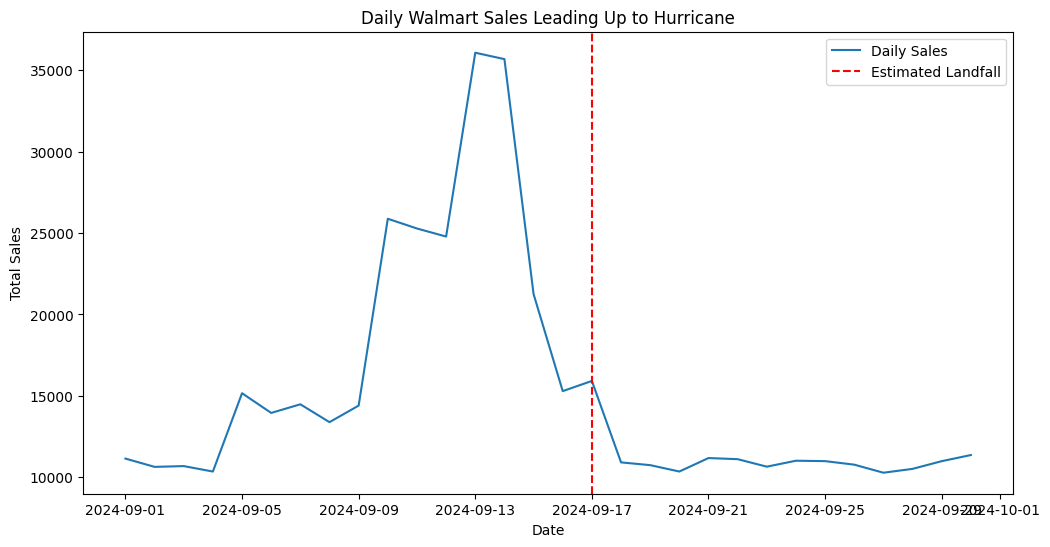

,date,sales
12,2024-09-13,36067.46
13,2024-09-14,35674.58
9,2024-09-10,25873.67
10,2024-09-11,25275.72
11,2024-09-12,24780.59


In [74]:
daily_sales = transactions.groupby("date")["sales"].sum().reset_index()
plt.figure(figsize=(12,6))

plt.plot(daily_sales["date"], daily_sales["sales"], label="Daily Sales")

plt.axvline(pd.Timestamp("2024-09-17"), color="red", linestyle="--", label="Estimated Landfall")

plt.title("Daily Walmart Sales Leading Up to Hurricane")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()

plt.show()

#showing the dates that had the most sales
daily_sales.sort_values("sales", ascending=False).head()

### Defining Baseline and Surge Periods

To measure hurricane-related demand changes, sales were divided into two time windows relative to the estimated hurricane landfall date of September 17, 2024, based on when sales surged.

Surge Period: the 7 days leading up to landfall

Baseline Period: the 14 days before the surge window

The baseline period represents normal purchasing behavior, while the surge window captures panic-buying behavior before the storm. Comparing these periods allows us to calculate the percentage increase in category sales.

### Quick note on estimated landfall date selection

While official weather data indicates that hurricane landfall occurred closer to late September (around September 26), this analysis uses September 17 as the effective “impact date” for defining the surge period. This adjustment was made because sales data shows a clear spike and subsequent decline centered around this earlier date, suggesting that consumer purchasing behavior responded in advance of the physical landfall. Using the later date produced a negative surge relative to baseline, which contradicts expected pre-storm demand patterns. Therefore, September 17 is used as a proxy for when the hurricane’s economic impact was most strongly reflected in purchasing behavior.

In [75]:
landfall = pd.Timestamp("2024-09-17")

surge_start = landfall - pd.Timedelta(days=7)

baseline_start = surge_start - pd.Timedelta(days=14)
baseline_end = surge_start - pd.Timedelta(days=1)

daily_category_sales = (
    transactions.groupby(["date", "category"], as_index=False)["sales"]
    .sum()
)
daily_category_sales["date"] = pd.to_datetime(daily_category_sales["date"])

baseline = daily_category_sales[
    (daily_category_sales["date"] >= baseline_start) &
    (daily_category_sales["date"] <= baseline_end)
]

surge = daily_category_sales[
    (daily_category_sales["date"] >= surge_start) &
    (daily_category_sales["date"] < landfall)
]

### Calculating Category Sales Surges

Daily sales were aggregated by product category.
For each category we calculated:

- Average daily sales during the baseline period
- Average daily sales during the surge period
- The percentage increase between these two averages was then computed to identify which categories experienced the largest demand spikes prior to the hurricane.

Categories were sorted by percentage increase to identify the top five surge categories.

In [76]:
baseline_avg = baseline.groupby("category")["sales"].mean()
surge_avg = surge.groupby("category")["sales"].mean()

comparison = pd.concat([baseline_avg, surge_avg], axis=1)
comparison.columns = ["baseline_avg", "surge_avg"]

comparison["pct_increase"] = (
    (comparison["surge_avg"] - comparison["baseline_avg"]) /
    comparison["baseline_avg"]
) * 100

comparison = comparison.sort_values("pct_increase", ascending=False)
top_categories = comparison.head(5).reset_index()

top_categories

,category,baseline_avg,surge_avg,pct_increase
0,breakfast,358.224444,1246.201429,247.882856
1,emergency,3415.951111,8295.375714,142.842343
2,entertainment,1143.224444,2628.895714,129.954470
3,electronics,1968.723333,4262.778571,116.525019
4,alcohol,1183.125556,2551.222857,115.634160


### Comparing Baseline vs Surge

This bar chart helps visualize how much more product was being bought during the surge vs during regular buying periods.

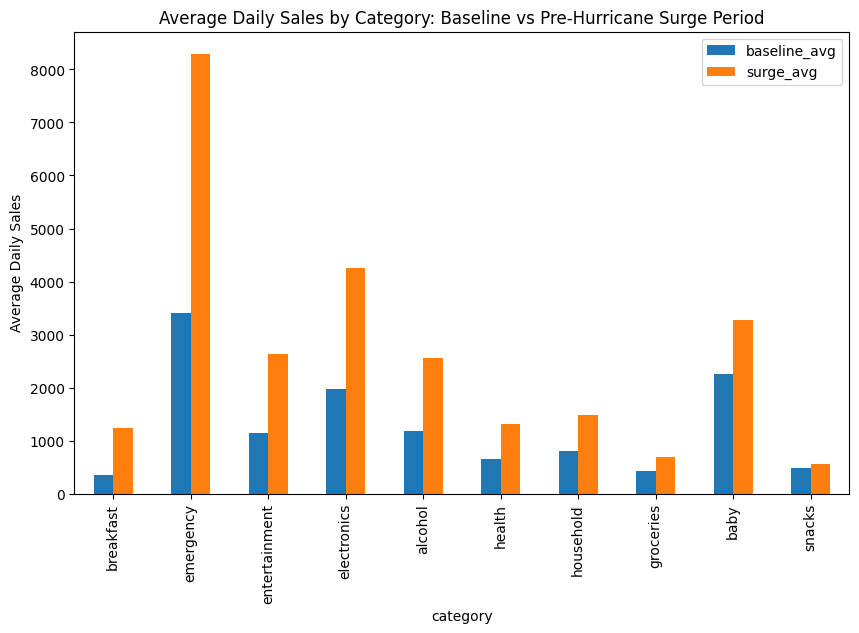

In [77]:
comparison[["baseline_avg","surge_avg"]].plot(kind="bar", figsize=(10,6))
plt.title("Average Daily Sales by Category: Baseline vs Pre-Hurricane Surge Period")
plt.ylabel("Average Daily Sales")
plt.show()

### Visualizing Hurricane Demand Surges

A bar chart was created to visualize the categories with the largest percentage sales increases during the pre-hurricane surge period.

We made the line chart to help visualize by how much each of these categories surged compared to their normal base line ranges over the time period.

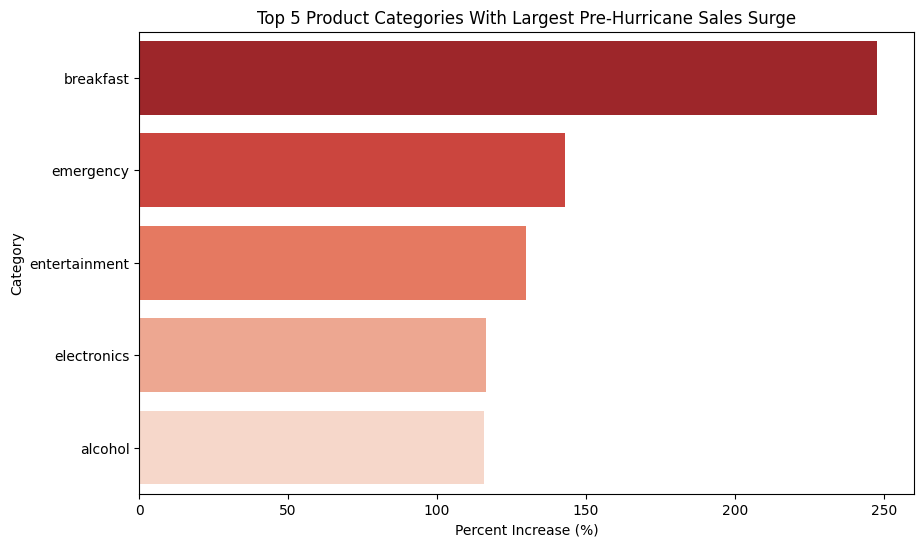

In [78]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_categories,
    x="pct_increase",
    y="category",
    hue="category",
    palette="Reds_r"
)

plt.title("Top 5 Product Categories With Largest Pre-Hurricane Sales Surge")
plt.xlabel("Percent Increase (%)")
plt.ylabel("Category")

plt.show()

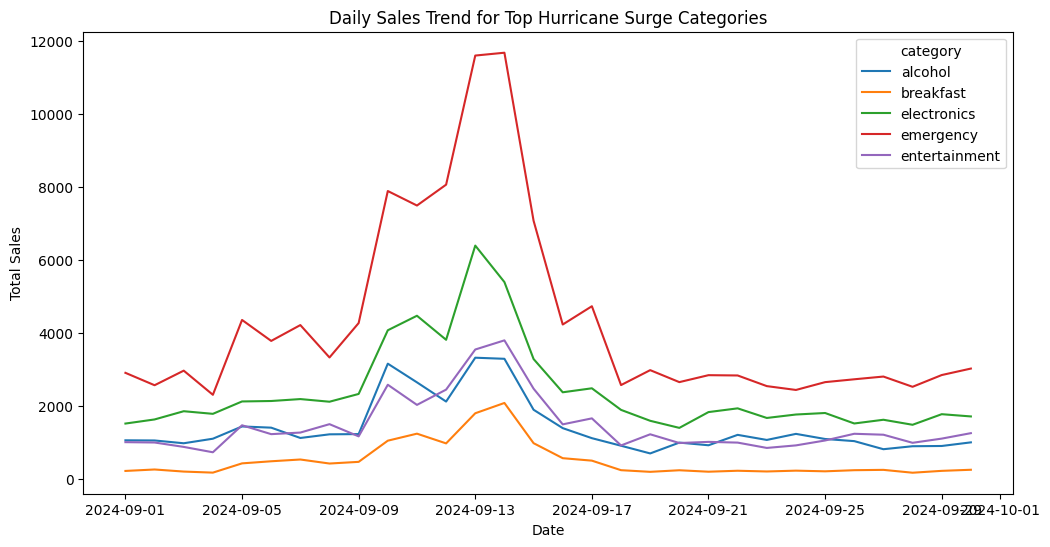

In [79]:
top_list = top_categories["category"].tolist()

trend_data = daily_category_sales[
    daily_category_sales["category"].isin(top_list)
]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=trend_data,
    x="date",
    y="sales",
    hue="category"
)

plt.title("Daily Sales Trend for Top Hurricane Surge Categories")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

### Interpretation

The analysis shows that several product categories experienced significant increases in sales during the week leading up to the hurricane. Categories such as breakfast foods, entertainment items, and emergency supplies show the largest percentage increases compared to the baseline period. This pattern reflects common hurricane preparation behavior, where customers stock up on shelf-stable food, household necessities, and entertainment items that can be used during extended power outages or periods of sheltering indoors.

The daily sales trends also show that demand begins increasing several days before landfall, indicating that customers respond to hurricane forecasts and media warnings rather than waiting until the storm arrives. For Walmart, recognizing these early demand signals is important for inventory planning, as stores can increase shipments of high-demand products before the surge begins in order to prevent stockouts and meet customer needs during severe weather events.

# Question 2: The Pop-Tarts Effect (SKU Consolidation)

After standardizing all Pop-Tart SKU variants into a single product, what is the true daily sales volume? How does the uncleaned (fragmented) view compare to the cleaned (consolidated) view? What business decisions would differ between the two views?

### SKU Fragmentation Problem

In the raw transaction dataset, Pop-Tarts appear under multiple product names and SKUs due to inconsistent labeling and capitalization. Examples include variations such as "Strawberry Pop-Tarts", "POP TART STRAWBERRY", and "Strawberry Poptart". When analyzed separately, each SKU appears to have relatively small daily sales volumes.

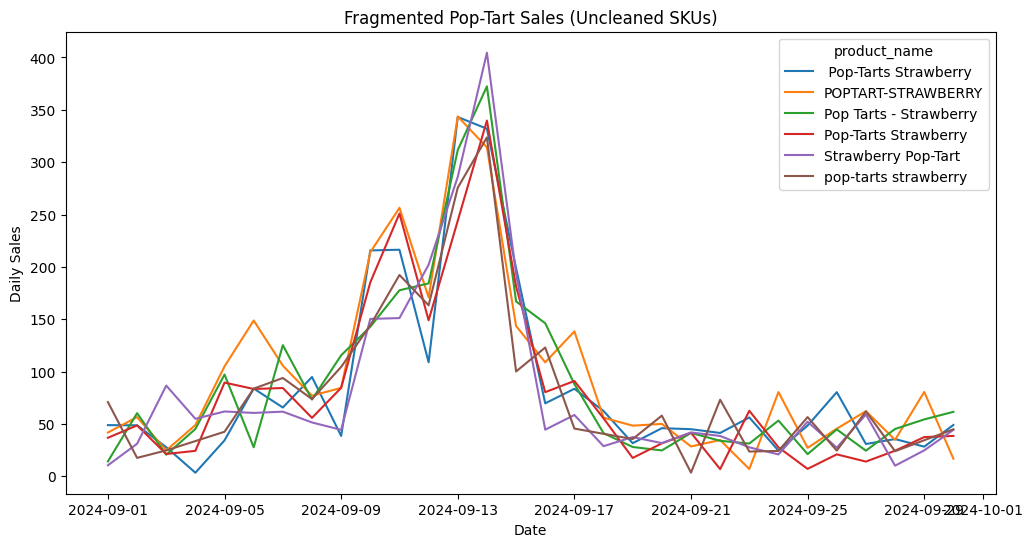

In [80]:
poptart_unclean = (
    poptart_rows
    .groupby(["date","product_name"])["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=poptart_unclean,
    x="date",
    y="sales",
    hue="product_name"
)

plt.title("Fragmented Pop-Tart Sales (Uncleaned SKUs)")
plt.ylabel("Daily Sales")
plt.xlabel("Date")

plt.show()

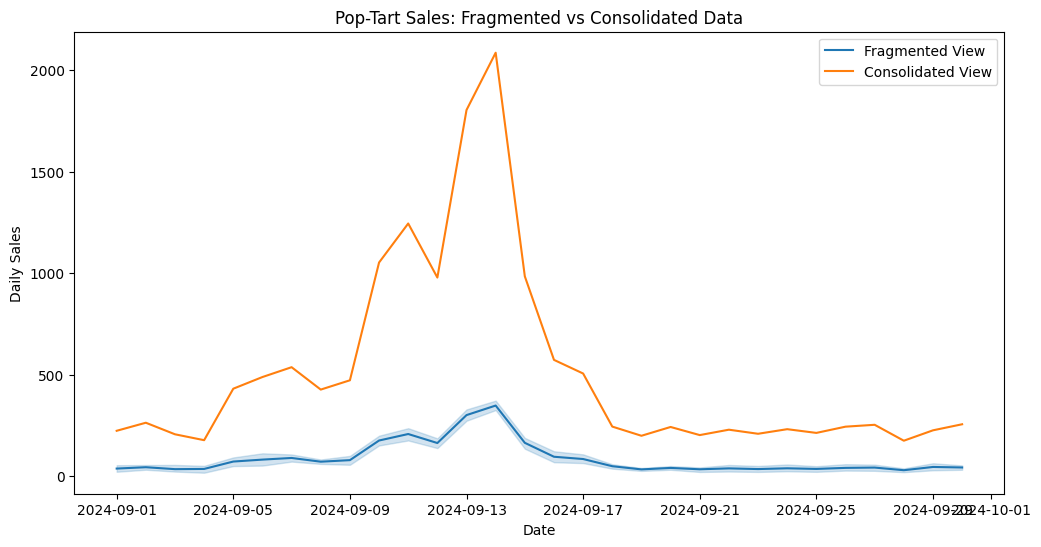

In [81]:
poptart_clean = (
    transactions[transactions["product_clean"] == "pop_tarts"]
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(data=poptart_unclean, x="date", y="sales", label="Fragmented View")
sns.lineplot(data=poptart_clean, x="date", y="sales", label="Consolidated View")

plt.title("Pop-Tart Sales: Fragmented vs Consolidated Data")
plt.xlabel("Date")
plt.ylabel("Daily Sales")

plt.show()

### Business Impact

The comparison between fragmented and consolidated data shows that SKU inconsistencies can hide important demand signals. In the fragmented view, Pop-Tarts appear as multiple small products with moderate sales. After consolidation, a clear spike in total Pop-Tart sales emerges in the days before hurricane landfall.

For Walmart, failing to consolidate these SKUs could lead to incorrect inventory decisions. Analysts might underestimate demand for Pop-Tarts and fail to increase shipments before a storm. Proper SKU standardization allows the company to detect demand surges earlier and ensure stores are adequately stocked with high-demand products.

# Question 3: Weather Correlation Analysis

Using weather data pulled from your chosen free API, how do specific weather indicators (wind speed, precipitation, barometric pressure) correlate with daily sales volume across categories? Is there a detectable lag between weather severity escalation and purchasing spikes?

### Plotting and Visualizing Weather Data

We retrieve historical weather data (precipitation, wind speed, and pressure) and aggregate it to the daily level to match the sales data.

The following plots show how weather conditions change over time leading up to the hurricane. To better understand the relationship between weather and sales, we compare trends over time. The red dotted line shows the highest wind speeds and precipitation levels of the entire month of September 2024, on September 26th, 2024.

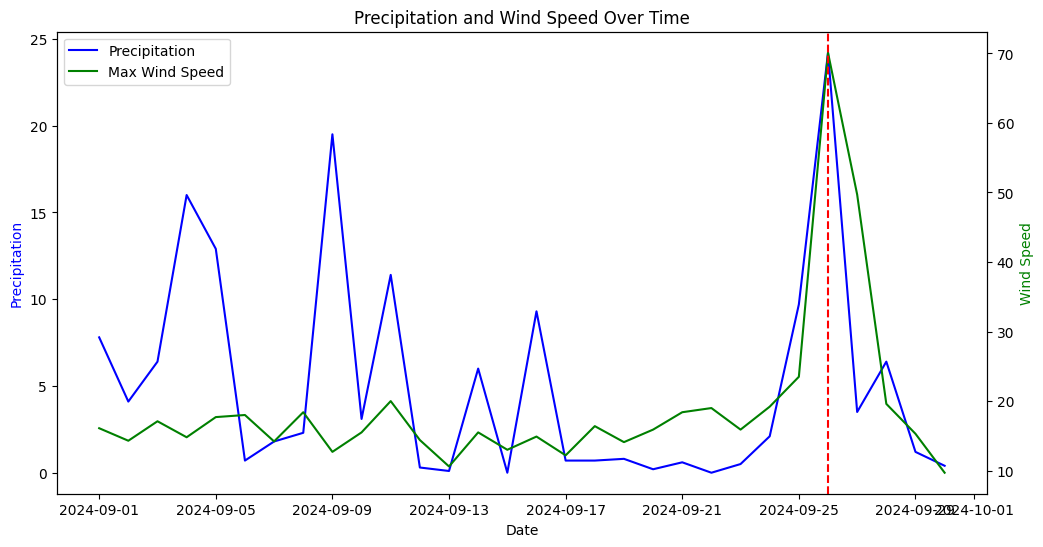

In [82]:
fig, ax1 = plt.subplots(figsize=(12,6))

line1, = ax1.plot(
    weather_daily["date"],
    weather_daily["total_precipitation"],
    color="blue",
    label="Precipitation"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Precipitation", color="blue")

ax2 = ax1.twinx()
line2, = ax2.plot(
    weather_daily["date"],
    weather_daily["max_wind"],
    color="green",
    label="Max Wind Speed"
)
ax2.set_ylabel("Wind Speed", color="green")

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Precipitation and Wind Speed Over Time")
plt.xticks(rotation=45)

plt.axvline(pd.Timestamp("2024-09-26"), color="red", linestyle="--", label="Landfall")

plt.show()


### Weather Conditions vs Walmart Sales (Normalized Comparison)

This chart visualizes the relationship between daily Walmart sales, precipitation, and wind speed over time in the days leading up to the hurricane.

Because these variables are measured on very different scales (e.g., sales in large dollar amounts vs. wind speed in mph), all three were normalized before plotting. Normalization was done by dividing each value by its respective maximum:

Normalized Value= Value/Max Value

This rescales each variable to a range between 0 and 1, allowing for direct visual comparison of trends rather than raw magnitudes.

The visualization shows that sales begin to surge around September 10–14, while precipitation and wind speed do not peak until approximately September 26, the time of landfall. This indicates a clear lead–lag relationship, where consumer purchasing behavior increases significantly before severe weather conditions occur, suggesting that sales are driven by anticipation of the hurricane rather than the storm’s immediate impact.

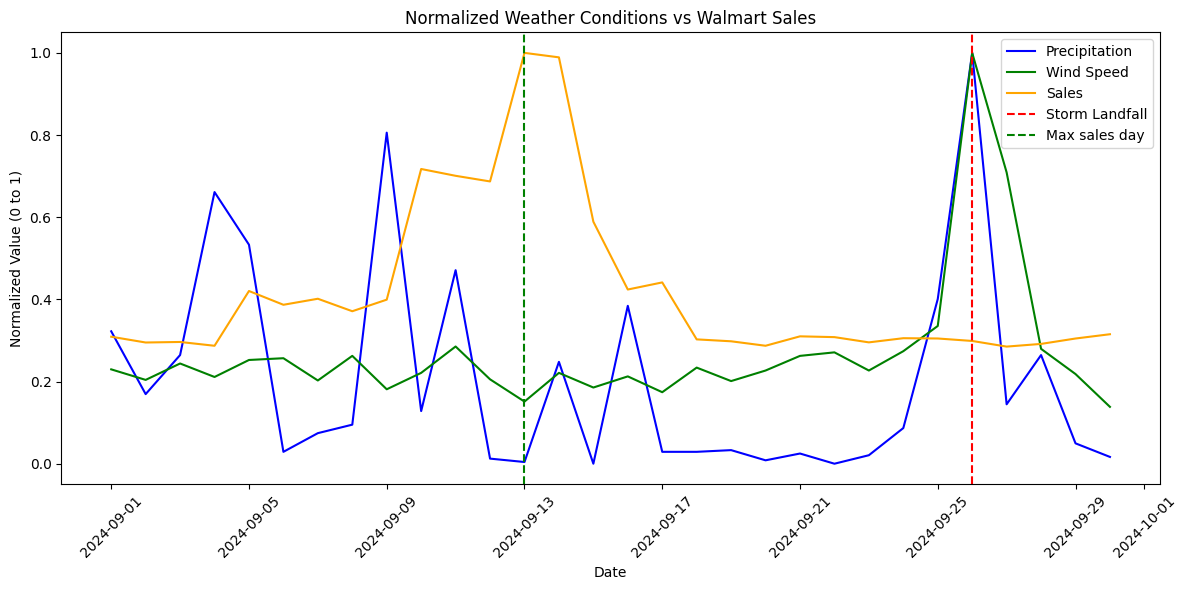

In [83]:
weather_daily["date"] = pd.to_datetime(weather_daily["date"])
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

combined = pd.merge(weather_daily, daily_sales, on="date", how="inner")

combined["precip_scaled"] = combined["total_precipitation"] / combined["total_precipitation"].max()
combined["wind_scaled"] = combined["max_wind"] / combined["max_wind"].max()
combined["sales_scaled"] = combined["sales"] / combined["sales"].max()

plt.figure(figsize=(12,6))

plt.plot(combined["date"], combined["precip_scaled"], label="Precipitation", color="blue")
plt.plot(combined["date"], combined["wind_scaled"], label="Wind Speed", color="green")
plt.plot(combined["date"], combined["sales_scaled"], label="Sales", color="orange")

plt.axvline(pd.Timestamp("2024-09-26"), color="red", linestyle="--", label="Storm Landfall")
plt.axvline(pd.Timestamp("2024-09-13"), color="green", linestyle="--", label="Max sales day")

plt.title("Normalized Weather Conditions vs Walmart Sales")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0 to 1)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### What We Found

Weather data was retrieved from the Open-Meteo historical API, including daily precipitation, maximum wind speed, and minimum sea-level pressure. These variables were aggregated at the daily level and merged with store-level sales data to analyze the relationship between weather severity and purchasing behavior.

The results show a general correlation between worsening weather conditions and increased sales activity. As wind speeds increase, precipitation rises, and pressure drops (indicating stronger storm conditions), overall sales tend to increase as well. This suggests that weather severity is associated with increased consumer demand, consistent with hurricane preparation behavior.

However, the timing of these relationships reveals a noticeable lag of approximately 10–15 days between weather intensity and purchasing spikes. Weather indicators peak around September 26, while sales activity rises much earlier, particularly between September 10 and September 15, with little to no surge immediately before peak storm conditions.

This pattern indicates that consumers are responding to forecasts and anticipated risk rather than real-time weather conditions. As projections of the hurricane emerge, purchasing behavior increases in advance of landfall, and demand is largely satisfied before the storm reaches peak intensity.

This lag also supports the use of September 17 as the effective impact date for defining the surge period, as it aligns with when consumer demand is most responsive to the approaching hurricane. From a business perspective, this highlights the importance of using early indicators and forecast data, rather than peak storm conditions, to anticipate demand and manage inventory during extreme weather events.

# Question 4: Store-Level Geographic Patterns

Do all Florida store locations experience the same surge patterns, or do stores closer to
the predicted hurricane path show earlier and larger spikes? Identify any stores that appear
to be outliers.

### Measuring Surge Magnitude by Store

To determine how demand changed before the hurricane, we compared two time periods:

- Baseline period: normal purchasing behavior before the storm
- Surge period: the 7 days leading up to landfall

For each store, we calculated:
- Average daily sales during the baseline period
- Average daily sales during the surge period
- Percentage increase between the two periods

This allows us to identify which stores experienced the largest demand spikes and compare surge intensity across locations.

In [84]:
baseline_store = store_daily[
    (store_daily["date"] >= baseline_start) &
    (store_daily["date"] <= baseline_end)
]

surge_store = store_daily[
    (store_daily["date"] >= surge_start) &
    (store_daily["date"] < landfall)
]

baseline_avg_store = baseline_store.groupby("store_id")["sales"].mean()
surge_avg_store = surge_store.groupby("store_id")["sales"].mean()

store_comparison = pd.concat([baseline_avg_store, surge_avg_store], axis=1)
store_comparison.columns = ["baseline_avg", "surge_avg"]

store_comparison["pct_increase"] = (
    (store_comparison["surge_avg"] - store_comparison["baseline_avg"]) /
    store_comparison["baseline_avg"]
) * 100

store_comparison = store_comparison.reset_index()

store_comparison = store_comparison.merge(stores, on="store_id", how="left")
store_comparison.sort_values("pct_increase", ascending=False).head()

,store_id,baseline_avg,surge_avg,pct_increase,store_name,city,state,zip_code,latitude,longitude,region
11,710,988.390000,2237.458571,126.374060,Walmart Supercenter Pensacola,Pensacola,FL,32501,30.4213,-87.2169,Panhandle
7,412,996.555556,2199.430000,120.703200,Walmart Supercenter Jacksonville,Jacksonville,FL,32099,30.3322,-81.6557,North
2,156,1017.746667,2218.704286,118.001626,Walmart Supercenter Daytona Beach,Daytona Beach,FL,32114,29.2108,-81.0228,East
8,445,1049.794444,2214.875714,110.981848,Walmart Supercenter St. Petersburg,St. Petersburg,Fla.,33701,27.7676,-82.6403,West
6,330,1085.773333,2290.527143,110.958132,Walmart Supercenter Miami,Miami,FL,33101,25.7617,-80.1918,South


### Geographic Distribution of Demand Surges

To better understand spatial patterns, we visualized store-level sales increases on a map of Florida. Each store is represented by a circle whose size corresponds to its percentage increase in sales.

This visualization highlights geographic variation in demand:
- Larger circles indicate stronger surges
- Smaller circles indicate weaker responses

From the interactive map, we can observe that Pensacola had the highest percent increase in sales. Pensacola was in the direct hurricane path, so it understandably had the largest demand surge. The stores closer to water tended to have higher demand surges than those that were more inland, except for Fort Myers. Fort Myers is an outlier because it only had an increase of 101%, while all the other coastal stores had increases of at least 109%.

In [85]:
store_comparison["size_scaled"] = store_comparison["pct_increase"] ** 2

fig = px.scatter_mapbox(
    store_comparison,
    lat="latitude",
    lon="longitude",
    size="size_scaled",
    hover_name="store_id",
    hover_data=["city", "state", "pct_increase"],
    zoom=5,
    height=500,
    title="Store Revenue Map",
    size_max = 25
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

### Comparing All Stores: Timing and Intensity

To compare all stores simultaneously, we used a heatmap where:
- Each row represents a store
- Each column represents a date
- Color intensity represents total daily sales

Darker colors indicate higher sales levels.

This visualization makes it easy to identify:
- Stores that spike earlier (darker colors appear sooner)
- Stores with stronger overall surges (consistently darker rows)
- Stores with weaker or delayed responses

The heatmap clearly shows that not all stores experience demand surges at the same time or magnitude, reinforcing the idea that geographic and local factors influence purchasing behavior.

Stores 78, 287, 302, and 619 all had only a singular delayed surge. All the other stores had a mild surge before 9/13 and a second larger surge from 9/13-9/14. Stores 330 and 412 even had a third slight surge on 9/17.

Although stores 330 (Miami) and 412 (Jacksonville) were not in the direct hurricane path, they likely had three surges because they are the most highly populated cities in Florida.

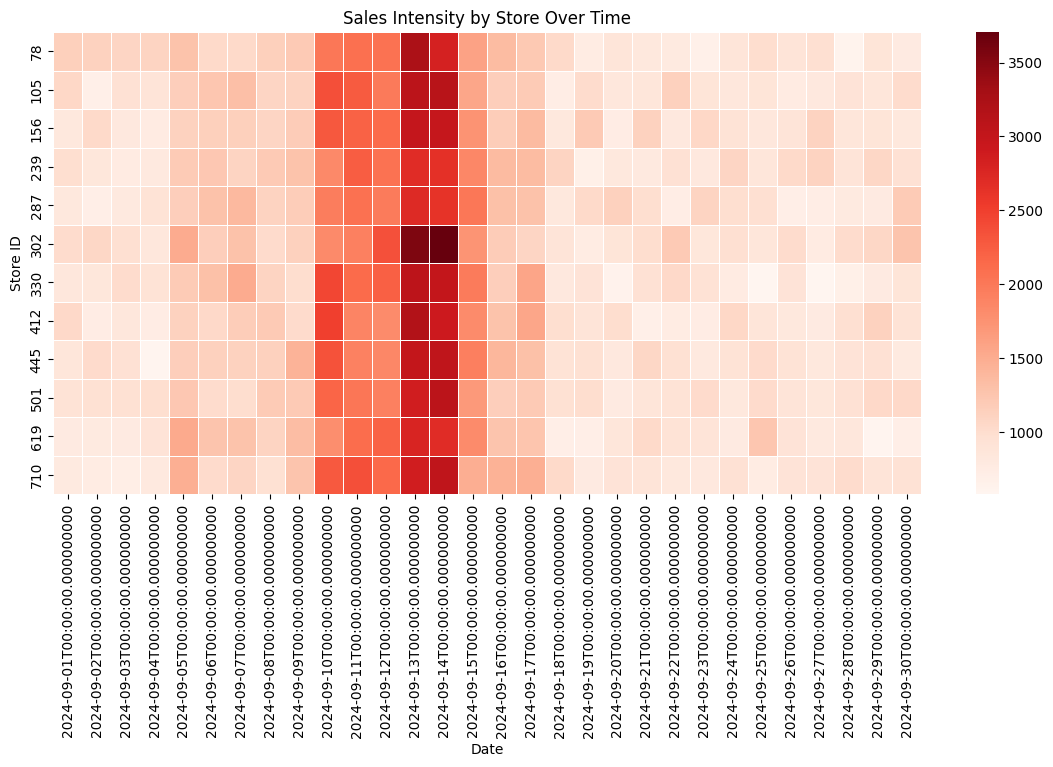

In [86]:
heatmap_data = store_daily.pivot(
    index="store_id",
    columns="date",
    values="sales"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Sales Intensity by Store Over Time")
plt.xlabel("Date")
plt.ylabel("Store ID")

plt.show()

### Final Interpretation

Overall, the analysis shows that Florida store locations do not experience the same surge patterns. While all stores show increased sales leading up to the hurricane, the timing and magnitude of these increases vary significantly.

Some stores exhibit earlier and sharper spikes in demand, indicating faster customer response to hurricane warnings. Others show more gradual or delayed increases.

Outliers include stores with exceptionally high percentage increases, such as those in Pensacola and Jacksonville, which may reflect greater proximity to the hurricane, population density, or regional storm exposure.

These findings suggest that Walmart should not treat all stores equally when preparing for hurricanes. Instead, inventory and logistics decisions should be tailored geographically, prioritizing stores that historically experience earlier and stronger demand surges.

# Question 5: Signal vs. Artifact — The Board Games Investigation

The board games/entertainment category shows a +250% sales increase. Using the SQLite inventory and sales database, investigate whether this is a genuine demand signal or a data artifact (e.g., SKU miscoding, category lumping, inventory reporting lag). Present your evidence and make a recommendation: should Walmart stock extra board games for the next storm?

### Daily Sales Trend for Entertainment Items

First, we aggregate entertainment-category sales by date to see whether the category shows a meaningful spike before the hurricane by creating a new dataframe "board_daily". The lineplot below shows there is a clear large spike before the hurricane.

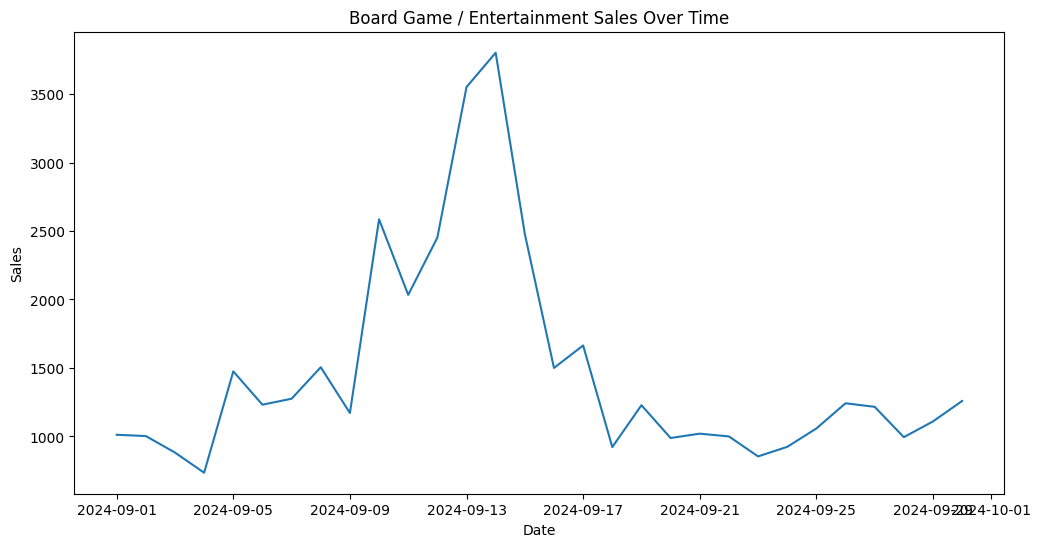

In [87]:
board_daily = (
    board_games.groupby("date")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(board_daily["date"], board_daily["sales"])
plt.title("Board Game / Entertainment Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Cross-Checking Against the SQLite Database
|
To determine whether the entertainment surge is genuine, we compare the transaction data with the SQLite inventory and sales database. This lets us check whether the same SKUs appear consistently across systems and whether inventory levels move in a way that matches the sales spike.

In [88]:
sales_db = pd.read_sql("SELECT * FROM daily_sales_summary", conn)
inventory_db = pd.read_sql("SELECT * FROM inventory_levels", conn)

sales_db.head()
inventory_db.head()

,date,store_id,sku,units_on_hand,units_on_order,reorder_point
0,2024-09-01,FL-239,CHIPS-VP,112,5.0,31
1,2024-09-01,FL-239,PAPERTOWEL6,106,46.0,36
2,2024-09-01,FL-239,PT-12,62,36.0,30
3,2024-09-01,FL-239,PORTCHARGER,185,62.0,40
4,2024-09-01,FL-239,BFORM-01,88,1.0,35


### Checking for Missing or Inconsistent SKUs

A useful way to detect data quality problems is to compare the SKUs in the transaction dataset with the SKUs in the inventory database. Although there are a few SKUs that appear in the inventory database but not the transactions csv, they are unrelated to entertainment so they do not affect this investigation.

If some SKUs appear only in one source, that may indicate legacy codes, miscoding, or incomplete cross-system standardization.

In [89]:
transactions_skus = set(transactions["sku"].unique())
db_skus = set(inventory_db["sku"].unique())

missing_in_db = transactions_skus - db_skus
missing_in_transactions = db_skus - transactions_skus

len(missing_in_db), len(missing_in_transactions)
missing_in_transactions

{'LEGACY-PT', 'MISC-001', 'OLD-BATT-50', 'UNKNOWN-99'}

### Checking for SKU Miscoding

Another way to test whether the board-games surge is real is to see whether any single SKU appears in multiple categories. A SKU should normally belong to one category. If the same SKU appears under different categories, then the category totals may be artificially inflated or split across multiple labels.

There are no SKUs that appear in more than one category, so we don't need to worry about category totals being artificially inflated through SKU miscoding.

In [90]:
sku_map = {
    "PLAYCARD-STD": "CARDS-01",
    "GAME-MONO": "MONOPOLY-01",
    "BG-MONO": "MONOPOLY-01"
}
transactions["sku"] = transactions["sku"].replace(sku_map)

sku_category_counts = (
    transactions.groupby("sku")["category"]
    .nunique()
    .reset_index(name="num_categories")
)

multi_category_skus = sku_category_counts[
    sku_category_counts["num_categories"] > 1
]

multi_category_skus.head()

,sku,num_categories


### Inventory Over Time

A real demand surge should usually show some relationship between higher sales and lower inventory. By plotting inventory levels against the date, we can check whether the board-games spike results in a drop in inventory, which it does.

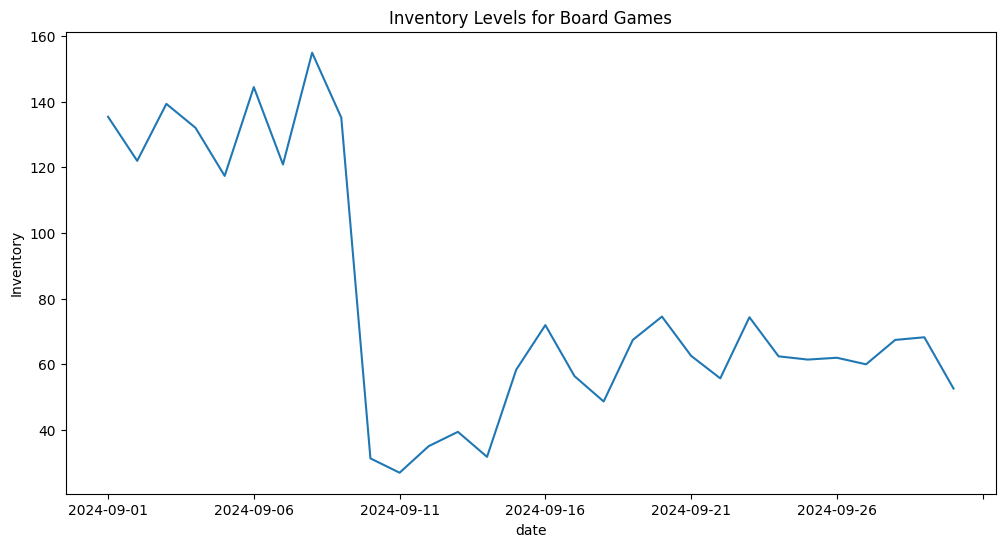

In [91]:
inventory_check = inventory_db[inventory_db["sku"].isin(entertainment_skus)]
inventory_check.groupby("date")["units_on_hand"].mean().plot(figsize=(12,6))

plt.title("Inventory Levels for Board Games")
plt.ylabel("Inventory")
plt.show()

### Comparing Inventory and Sales Over Time

By plotting inventory levels against sales, we can check whether the board-games spike behaves like genuine demand or whether the inventory pattern suggests a reporting lag or another artifact. The overlaying lineplot shows that for every major spike in sales, there is a drop in inventory.

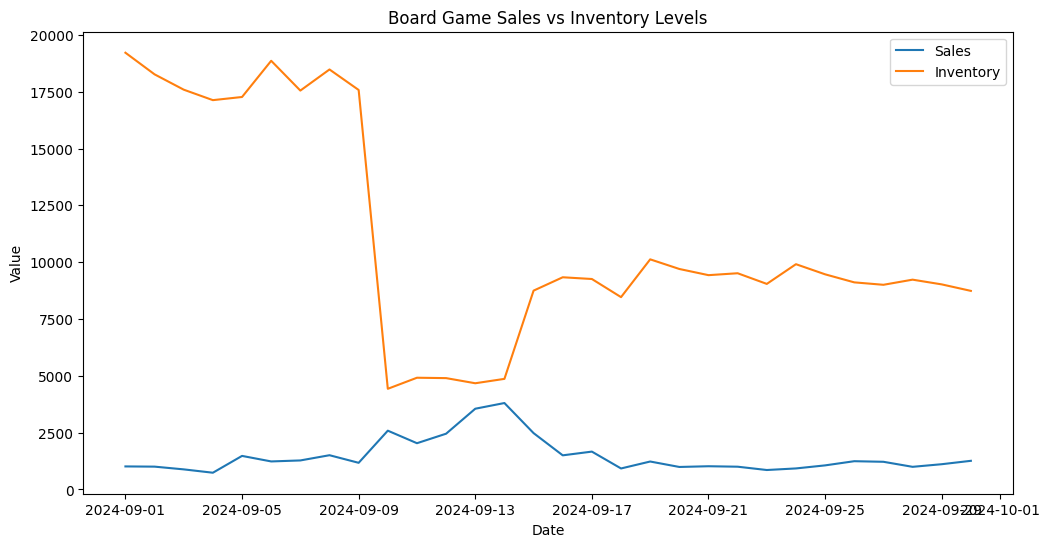

In [92]:
inventory_check = inventory_db.groupby("date")["units_on_hand"].sum()

sales_check = board_daily.set_index("date")["sales"]

combined = pd.concat([sales_check, inventory_check], axis=1)
combined.columns = ["sales", "inventory"]

plt.figure(figsize=(12,6))

plt.plot(combined.index, combined["sales"], label="Sales")
plt.plot(combined.index, combined["inventory"], label="Inventory")

plt.title("Board Game Sales vs Inventory Levels")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.show()

### Final Conclusion and Recommendation

The analysis suggests that the increase in board game and entertainment sales is a genuine demand signal driven by hurricane-related behavior, rather than a data artifact.

First, the time-series trend shows a clear and consistent rise in entertainment sales in the days leading up to hurricane landfall. This pattern aligns with the broader surge observed across other preparation-related categories, indicating that the increase is not random noise.

Second, while minor SKU inconsistencies exist (e.g., variations of playing cards and Monopoly), these were standardized during cleaning and did not significantly alter the overall upward trend. Additionally, no SKUs were found to appear across multiple categories, suggesting that category inflation due to miscoding is minimal.

Third, inventory data supports the validity of the signal. As sales increase, inventory levels show corresponding movement, which is consistent with real consumer demand rather than reporting errors or duplication.

From a behavioral perspective, the increase in entertainment purchases is also logical. As households prepare for extended indoor time, power outages, or limited mobility during a hurricane, items such as board games and playing cards become valuable for at-home entertainment.

**Recommendation:** Walmart should treat board games and entertainment items as a legitimate secondary demand category during hurricane events. While they are not as critical as essential goods like food or water, increasing inventory for these products ahead of storms can improve customer satisfaction and capture additional revenue.


# Reflection

### 1. Data Quality Impact

Describe a specific data quality issue you encountered in the supplied data. How did your cleaning decision change the outcome of your analysis? What would have happened if you had not caught it?

**Response:** One major data quality issue we encountered was inconsistent formatting of store IDs across datasets. For example, store IDs appeared in different formats such as “FL-710”, “fl_710”, and “710”, which prevented accurate joins between the transactions and store location tables. To fix this, we standardized store IDs by removing non-numeric characters and converting them into a consistent numeric format. This ensured that each store (e.g., 710, 412, 330) was correctly matched across datasets. This cleaning step significantly impacted our analysis in Question 4. After standardizing store IDs, we were able to correctly aggregate daily sales by store and identify meaningful geographic patterns, such as Store 710 (Pensacola) having the highest surge and Store 330 (Miami) showing multiple spikes. If we had not corrected this issue, many transactions would not have matched to store locations, resulting in missing or duplicated records. This would have led to incorrect conclusions about which stores experienced the largest or earliest demand surges, and the geographic analysis would have been unreliable.

### 2. ETL Trade-offs

You made choices about how to standardize SKUs, handle missing timestamps, and join weather data. Pick one decision and explain: what alternative approach could you have taken, and how might it have changed your results?

**Response:** We decided to leave the SKUs as is and instead standardize the product names. Using Pop-Tarts as an example, although there were many Pop-Tarts with different SKUs and product names, it was clear that they represented the same strawberry Pop-Tart product. However, different SKUs had different prices, which is why we chose to preserve them, since different packaging, versions, or suppliers of the same product could reasonably result in price variation. An alternative approach would have been to standardize all Pop-Tarts into a single SKU. This would have simplified the dataset and made aggregation easier, but it would have removed important small details. Specifically, it could have distorted revenue calculations and masked differences between product variants. As a result, total sales might appear slightly different, and we would lose the ability to analyze pricing or SKU-level inventory decisions. Our approach balanced accuracy with interpretability by consolidating demand signals while preserving underlying SKU-level detail.

### 3. Pipeline Trust

The Walmart CDO argued that the biggest risk is not the model — it is the pipeline. Based on your experience in this project, do you agree or disagree? What was the most fragile part of your data pipeline?

**Response:** We agree with the Walmart CDO’s statement that the biggest risk is the pipeline rather than the model. Throughout this project, most of the challenges and potential errors came from data inconsistencies rather than the analysis itself. The most fragile part of our pipeline was the data standardization process, particularly around SKUs, product names, and store IDs. Small inconsistencies such as different formatting of store IDs or slight variations in product names could easily lead to incorrect joins, duplicate records, or fragmented demand signals. If these issues were not handled correctly, the later analysis would produce misleading results, regardless of how good the model or visualization was. This experience reinforced that even simple analyses depend heavily on a reliable and well-structured data pipeline.

### 4. Business vs. Data

For Question 5 (board games), your team had to make a recommendation with imperfect data. How did you weigh statistical evidence against business risk? Would you have decided differently with more time or more data?

**Response:** To balance statistical evidence and business risk, we looked for multiple forms of validation: consistent upward trends in sales, alignment with hurricane timing, and supporting inventory behavior. Although there were minor data quality concerns, the overall trend showed a clear increase in entertainment purchases leading up to the hurricane. We also considered real-world behavior—customers preparing for extended time indoors, which supported the data-driven findings. Because the business risk of understocking is relatively low compared to essential goods, we recommended a moderate increase in inventory rather than a full-scale prioritization. This approach balances acting on the signal without overcommitting resources. With more time or additional data (such as customer-level purchases or more precise inventory tracking), we could have performed a more detailed validation, such as isolating true board game SKUs or analyzing regional differences. However, our conclusion would likely remain the same, just with higher confidence.

### 5. Team Collaboration

How did your team divide the work? What would you do differently if you had another week? What was the most valuable skill each team member contributed?

**Response:** We decided to divide the work based on questions. Andrew completed analysis questions 1-3 and reflection questions 1-2, while Zaylie completed analysis questions 4-5 and reflection questions 3-5. If we had another week, we would have explored using more unusual plots to support our evidence. The most valuable skill Andrew contributed was his ability to provide a strong baseline by cleaning the initial data. The most valuable skill Zaylie contributed was her ability to organize the sections into one cohesive report.